In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import dask

In [1]:
from pyhdf.SD import SD, SDC

In [3]:
modis_ld_path = glob.glob('G:/modis_landcover/*.hdf')

In [4]:
modis_ld_path

['G:/modis_landcover\\MCD12C1.A2001001.061.2022146170409.hdf',
 'G:/modis_landcover\\MCD12C1.A2002001.061.2022149015010.hdf',
 'G:/modis_landcover\\MCD12C1.A2003001.061.2022151221423.hdf',
 'G:/modis_landcover\\MCD12C1.A2004001.061.2022154032517.hdf',
 'G:/modis_landcover\\MCD12C1.A2005001.061.2022154061622.hdf',
 'G:/modis_landcover\\MCD12C1.A2006001.061.2022202141607.hdf',
 'G:/modis_landcover\\MCD12C1.A2007001.061.2022154134516.hdf',
 'G:/modis_landcover\\MCD12C1.A2008001.061.2022159101912.hdf',
 'G:/modis_landcover\\MCD12C1.A2009001.061.2022160072200.hdf',
 'G:/modis_landcover\\MCD12C1.A2010001.061.2022161022952.hdf',
 'G:/modis_landcover\\MCD12C1.A2011001.061.2022162024514.hdf',
 'G:/modis_landcover\\MCD12C1.A2012001.061.2022162172724.hdf',
 'G:/modis_landcover\\MCD12C1.A2013001.061.2022165063153.hdf',
 'G:/modis_landcover\\MCD12C1.A2014001.061.2022165213124.hdf',
 'G:/modis_landcover\\MCD12C1.A2015001.061.2022166123617.hdf',
 'G:/modis_landcover\\MCD12C1.A2016001.061.202216801053

In [6]:
modis_ld_try = SD(modis_ld_path[0], SDC.READ) 

In [10]:
IGBP = modis_ld_try.select('Majority_Land_Cover_Type_1')

In [12]:
IGBP_data = IGBP[:,:].astype(np.float64)

In [14]:
IGBP_data.shape

(3600, 7200)

In [19]:
lat_list = np.arange(-89.975, 90, 0.05)
lon_list = np.arange(-179.975, 180, 0.05)

In [21]:
lat_list[3580:3600]

array([89.025, 89.075, 89.125, 89.175, 89.225, 89.275, 89.325, 89.375,
       89.425, 89.475, 89.525, 89.575, 89.625, 89.675, 89.725, 89.775,
       89.825, 89.875, 89.925, 89.975])

In [20]:
print(len(lat_list) , len(lon_list))

3600 7200


In [31]:
IGBP_xr = xr.DataArray([IGBP_data[::-1,]], coords=[[2001], lat_list, lon_list], dims=['year','lat', 'lon'])

In [32]:
IGBP_xr

<xarray.DataArray (year: 1, lat: 3600, lon: 7200)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * year     (year) int32 2001
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.87 89.92 89.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0

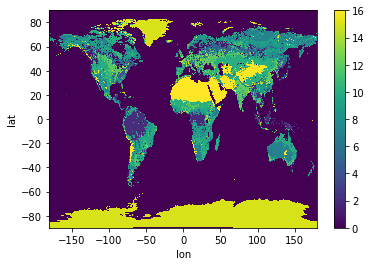

In [28]:
IGBP_xr.plot()

## 读取所有年份 然后导出成nc

In [29]:
lat_list = np.arange(-89.975, 90, 0.05)
lon_list = np.arange(-179.975, 180, 0.05)

In [36]:
modis_ld_path[0][28:32]

'2001'

In [39]:
def read_hdfs(path):
    modis_ld = SD(path, SDC.READ)
    IGBP = modis_ld.select('Majority_Land_Cover_Type_1')
    IGBP_data = IGBP[:,:].astype(np.float64)
    
    year = int(path[28:32])
    IGBP_xr = xr.DataArray([IGBP_data[::-1,]], coords=[[year], lat_list, lon_list], dims=['year','lat', 'lon'])
    
    return IGBP_xr

In [40]:
modis_ld_all = []
for modis_path_n in modis_ld_path:
    print(modis_path_n)
    IGBP_n = read_hdfs(modis_path_n)
    modis_ld_all.append(IGBP_n)
    
modis_ld_all = xr.concat(modis_ld_all, dim='year')

G:/modis_landcover\MCD12C1.A2001001.061.2022146170409.hdf
G:/modis_landcover\MCD12C1.A2002001.061.2022149015010.hdf
G:/modis_landcover\MCD12C1.A2003001.061.2022151221423.hdf
G:/modis_landcover\MCD12C1.A2004001.061.2022154032517.hdf
G:/modis_landcover\MCD12C1.A2005001.061.2022154061622.hdf
G:/modis_landcover\MCD12C1.A2006001.061.2022202141607.hdf
G:/modis_landcover\MCD12C1.A2007001.061.2022154134516.hdf
G:/modis_landcover\MCD12C1.A2008001.061.2022159101912.hdf
G:/modis_landcover\MCD12C1.A2009001.061.2022160072200.hdf
G:/modis_landcover\MCD12C1.A2010001.061.2022161022952.hdf
G:/modis_landcover\MCD12C1.A2011001.061.2022162024514.hdf
G:/modis_landcover\MCD12C1.A2012001.061.2022162172724.hdf
G:/modis_landcover\MCD12C1.A2013001.061.2022165063153.hdf
G:/modis_landcover\MCD12C1.A2014001.061.2022165213124.hdf
G:/modis_landcover\MCD12C1.A2015001.061.2022166123617.hdf
G:/modis_landcover\MCD12C1.A2016001.061.2022168010533.hdf
G:/modis_landcover\MCD12C1.A2017001.061.2022168170603.hdf
G:/modis_landc

In [43]:
modis_ld_all.name = 'modis_landcover'

In [44]:
modis_ld_all

<xarray.DataArray 'modis_landcover' (year: 22, lat: 3600, lon: 7200)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.87 89.92 89.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0

In [46]:
modis_ld_all.to_netcdf('G:/modis_landcover/modis_IGBP_2001_2022.nc',
                       encoding = {'modis_landcover':{"zlib": True, "complevel": 9}} )

In [49]:
modis_ld_all = modis_ld_all.sel(lat = slice(30, 70), lon = slice(90, 130))

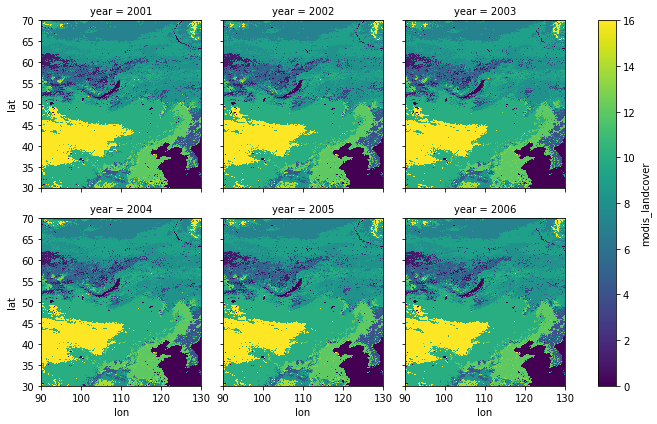

In [50]:
modis_ld_all[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap = 3)

In [52]:
modis_ld_all = modis_ld_all.where(modis_ld_all>0)
modis_ld_all = modis_ld_all.where(modis_ld_all<11)

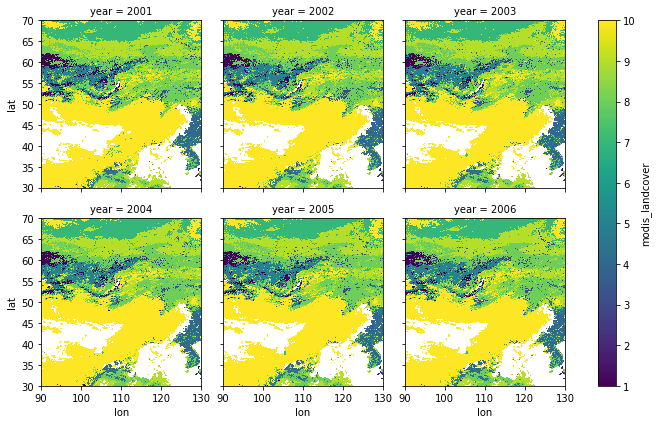

In [53]:
modis_ld_all[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap = 3)

In [2]:
with xr.open_dataarray('G:/modis_landcover/modis_IGBP_2001_2022.nc') as ld_data:
    modis_ld_global = ld_data

In [3]:
modis_ld_global

<xarray.DataArray 'modis_landcover' (year: 22, lat: 3600, lon: 7200)>
[570240000 values with dtype=float64]
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.87 89.92 89.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0

## 抽一个点看看

In [56]:
modis_ld_point = modis_ld_all.sel(lat = 45, lon = 120, method= 'nearest')

In [57]:
modis_ld_point

<xarray.DataArray 'modis_landcover' (year: 22)>
array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10.])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
    lat      float64 45.02
    lon      float64 120.0

In [60]:
len(np.unique(modis_ld_point.values))

1

In [62]:
np.isnan(modis_ld_point.values).all()

False

In [4]:
def ld_unchanged(ld_st):
    if np.isnan(ld_st).all():
        change = 2
    else:
        ld_len = len(np.unique(ld_st))
        if ld_len > 1:
            change = 1
        else:
            change = 0
    return change    

In [64]:
ld_unchanged(modis_ld_point.values)

0

In [65]:
ld_change =  xr.apply_ufunc(
    ld_unchanged,
    modis_ld_all,
    input_core_dims=[['year']],
    output_core_dims=[[]],
    vectorize= True
)

In [66]:
ld_change

<xarray.DataArray 'modis_landcover' (lat: 800, lon: 800)>
array([[0, 2, 2, ..., 2, 2, 2],
       [0, 2, 2, ..., 2, 2, 2],
       [0, 0, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 1, 2, 2],
       [1, 1, 0, ..., 0, 0, 1],
       [0, 1, 1, ..., 0, 0, 1]])
Coordinates:
  * lat      (lat) float64 30.02 30.07 30.12 30.17 ... 69.82 69.87 69.92 69.97
  * lon      (lon) float64 90.03 90.08 90.13 90.18 ... 129.8 129.9 129.9 130.0

In [67]:
modis_ld_filtered = modis_ld_all.where(ld_change == 0)

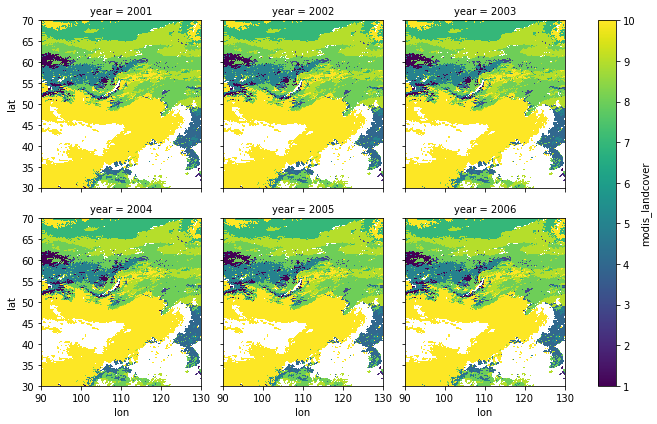

In [68]:
modis_ld_filtered[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap = 3)

## 读取一下 vod 数据

In [2]:
with xr.open_dataset('D:/aithc/data/VOD_1987.nc') as data:
    vod_data = data['vod']

In [3]:
vod_data

<xarray.DataArray 'vod' (time: 12, lat: 720, lon: 1440)>
[12441600 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 1987-07-08 1987-07-23 ... 1987-12-23
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88

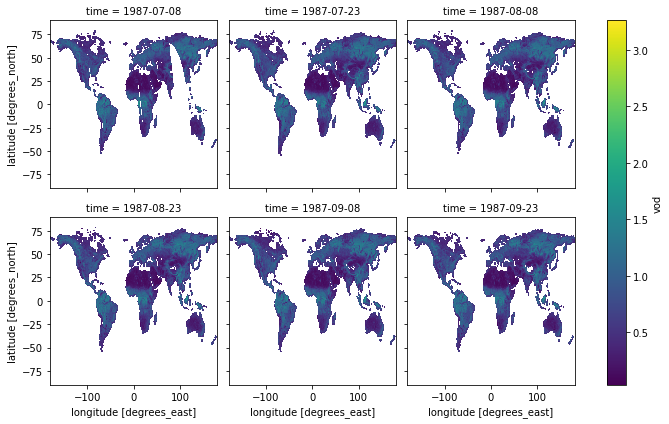

In [4]:
vod_data[0:6].plot(x = 'lon', y = 'lat', col = 'time', col_wrap = 3)

In [5]:
vod_data.lat.values[700:]

array([-85.125, -85.375, -85.625, -85.875, -86.125, -86.375, -86.625,
       -86.875, -87.125, -87.375, -87.625, -87.875, -88.125, -88.375,
       -88.625, -88.875, -89.125, -89.375, -89.625, -89.875])

## 做一个 vod分辨率的landcover

In [28]:
with xr.open_dataarray('G:/modis_landcover/modis_IGBP_2001_2022.nc') as ld_data:
    modis_ld_global = ld_data

In [51]:
modis_ld_global

<xarray.DataArray 'modis_landcover' (year: 22, lat: 3600, lon: 7200)>
[570240000 values with dtype=float64]
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 -89.97 -89.92 -89.88 -89.83 ... 89.87 89.92 89.97
  * lon      (lon) float64 -180.0 -179.9 -179.9 -179.8 ... 179.9 179.9 180.0

In [40]:
modis_ld_global.year.values[1]

2002

## 这样逐格点循环  太慢了。。

In [42]:
ld_vod = np.full((720, 1440), np.nan)

for year in range(22):
    print(modis_ld_global.year.values[year])
    for i in range(720):
        for j in range(1440):
            ld_values = modis_ld_global[year].values
            block_values = ld_values[i*5:(i+1)*5 , j*5:(j+1)*5]
            ld_vod[i,j] = stats.mode(np.reshape(block_values, 25))[0][0]
    
    ld_vod_year = xr.DataArray([ld_vod], 
                               coords = [[modis_ld_global.year.values[year]],vod_data.lat.values ,vod_data.lon.values ],
                               dims = ['year','lat','lon'])
    ld_vod_year.name = 'landcover'
    ld_vod_year.to_netcdf("G:/modis_landcover/landcover_vod_{}.nc".format(modis_ld_global.year.values[year]), 
                          encoding = {'modis_landcover':{"zlib": True, "complevel": 9}})

2001


KeyboardInterrupt: 

In [50]:
print(i * j /3600)

11.7875


## 还是用 中位数吧

In [53]:
modis_ld_vod = []
for i in range(len(modis_ld_global)):
    modis_ld_vod.append(modis_ld_global[i].coarsen(lat = 5, lon = 5).median())
modis_ld_vod = xr.concat(modis_ld_vod, dim = 'year') 

In [54]:
modis_ld_vod

<xarray.DataArray 'modis_landcover' (year: 22, lat: 720, lon: 1440)>
array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0., 15., 15., ..., 15., 15., 15.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0., 15., 15., ..., 15., 15., 15.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0., 15., 15., ..., 15., 15., 15.],
        ...,
...
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0., 15., 15., ..., 15., 15., 15.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0., 15., 15., ..., 15., 15., 15.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 -89.88 -89.63 -89.38 -89.13 ... 89.37 89.62 89.87
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

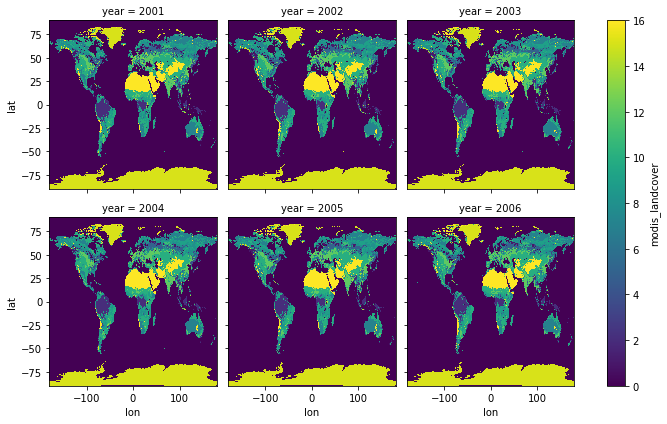

In [55]:
modis_ld_vod[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap=3)

In [56]:
modis_ld_vod = modis_ld_vod.where(modis_ld_vod>0)
modis_ld_vod = modis_ld_vod.where(modis_ld_vod<12)

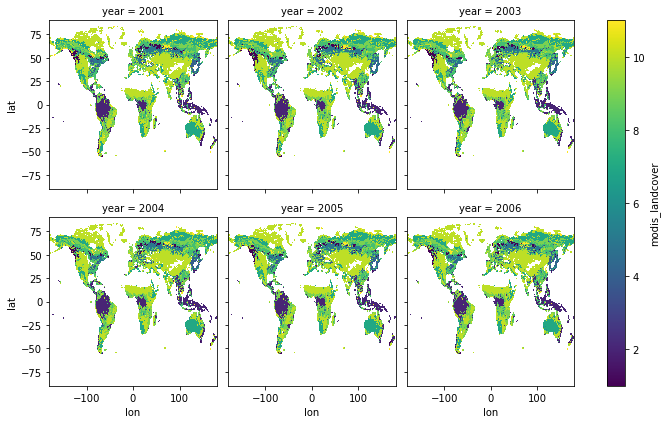

In [57]:
modis_ld_vod[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap=3)

In [58]:
ld_change_vod =  xr.apply_ufunc(
    ld_unchanged,
    modis_ld_vod,
    input_core_dims=[['year']],
    output_core_dims=[[]],
    vectorize= True
)

In [59]:
modis_ld_vod_filtered = modis_ld_vod.where(ld_change_vod == 0)

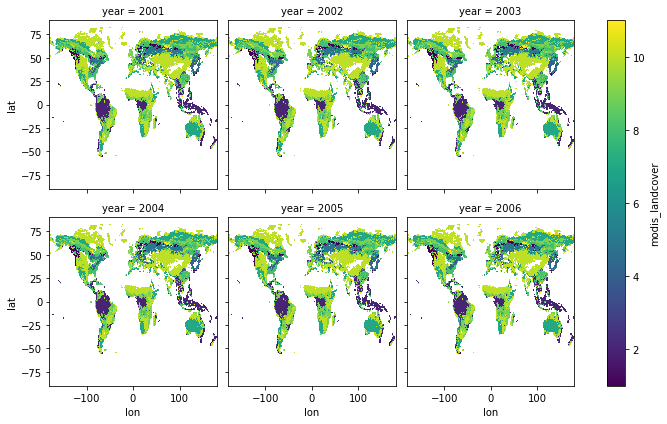

In [60]:
modis_ld_vod_filtered[0:6].plot(x = 'lon', y = 'lat', col = 'year', col_wrap=3)

In [61]:
modis_ld_vod_filtered

<xarray.DataArray 'modis_landcover' (year: 22, lat: 720, lon: 1440)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 -89.88 -89.63 -89.38 -89.13 ... 89.37 89.62 89.87
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [62]:
ld_change_vod_check =  xr.apply_ufunc(
    ld_unchanged,
    modis_ld_vod_filtered,
    input_core_dims=[['year']],
    output_core_dims=[[]],
    vectorize= True
)

In [64]:
np.unique(ld_change_vod_check.values)

array([0, 2])

In [65]:
modis_ld_vod_filtered[0].to_netcdf("G:/modis_landcover/landcover_vod_mask.nc", 
                          encoding = {'modis_landcover':{"zlib": True, "complevel": 9}})

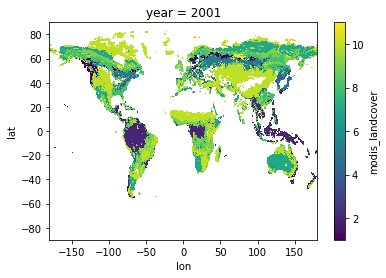

In [6]:
with xr.open_dataset("G:/modis_landcover/landcover_vod_mask.nc") as ld:
    ld_vod = ld['modis_landcover']
    ld_vod.plot()

In [7]:
ld_vod

<xarray.DataArray 'modis_landcover' (lat: 720, lon: 1440)>
[1036800 values with dtype=float64]
Coordinates:
    year     int64 ...
  * lat      (lat) float64 -89.88 -89.63 -89.38 -89.13 ... 89.37 89.62 89.87
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [9]:
vod_data

<xarray.DataArray 'vod' (time: 12, lat: 720, lon: 1440)>
[12441600 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 1987-07-08 1987-07-23 ... 1987-12-23
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88

In [13]:
vod_data_filtered = vod_data.where(ld_vod.values >0)

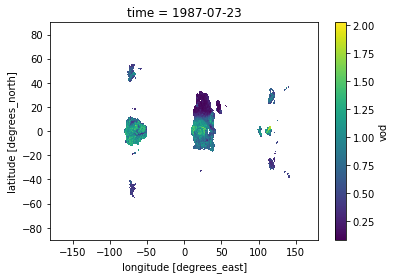

In [20]:
vod_data_filtered[1].plot()

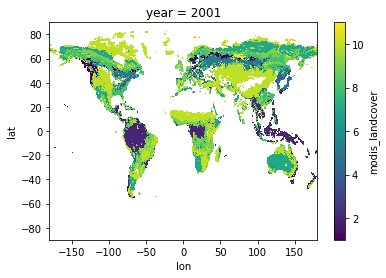

In [19]:
ld_vod.where(ld_vod > 0).plot()

In [21]:
np.sum(ld_vod.lat.values == vod_data.lat.values)

0

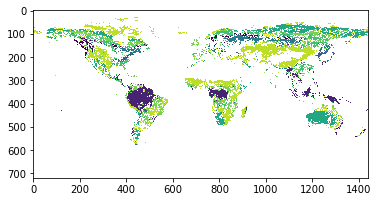

In [27]:
plt.imshow(ld_vod.values[::-1,:])

In [28]:
ld_vod = xr.DataArray(ld_vod.values[::-1,:], coords=[vod_data.lat, vod_data.lon ], dims = ['lat','lon'])

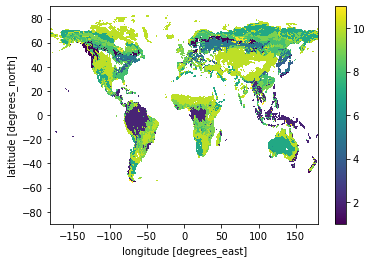

In [30]:
ld_vod.plot()

In [31]:
ld_vod.name = 'modis_landcover'

In [34]:
vod_data_filtered = vod_data.where(ld_vod>0)

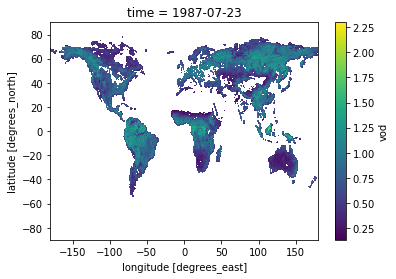

In [35]:
vod_data_filtered[1].plot()

In [36]:
ld_vod.to_netcdf("G:/modis_landcover/landcover_vod_mask.nc", 
                encoding = {'modis_landcover':{"zlib": True, "complevel": 9}})

## 还得再弄一个 gimms ndvi格网的

In [5]:
# 读一个 gimms ndvi数据
with xr.open_dataset(r'G:/gimms_3g_2022/ndvi3g_geo_v1_1_1982_0106.nc4') as ndvi_data:
    gimms_ndvi = ndvi_data

In [6]:
gimms_ndvi

<xarray.Dataset>
Dimensions:     (lat: 2160, lon: 4320, nv: 2, time: 12)
Coordinates:
  * time        (time) datetime64[ns] 1982-01-08 1982-01-24 ... 1982-06-23
  * lon         (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0
  * lat         (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
Dimensions without coordinates: nv
Data variables:
    crs         int32 ...
    time_bnds   (time, nv) datetime64[ns] ...
    satellites  (time) float32 ...
    ndvi        (time, lat, lon) float32 ...
    percentile  (time, lat, lon) float32 ...
Attributes: (12/19)
    publisher_type:         institution
    publisher_institution:  Oak Ridge National Laboratory Distributed Active ...
    publisher_url:          daac.ornl.gov
    publisher_email:        uso@daac.ornl.gov
    filename:               ndvi3g_geo_v1_1_1982_0106.nc4
    institution:            NASA/GSFC GIMMS
    ...                     ...
    southernmost_latitude:  -90
    westernmost_longitude:  -180
    easternmost_longitude:  180
    reference:              Pinzon, J.E. and C.J. Tucker. 2014. A Non-Station...
    comments:               Version 1.1 includes three major fixes (a- c), an...
    Conventions:            CF-1.6

In [7]:
gimms_ndvi.nv

<xarray.DataArray 'nv' (nv: 2)>
array([0, 1], dtype=int64)
Dimensions without coordinates: nv

In [8]:
gimms_ndvi_percentile = gimms_ndvi['percentile']

In [9]:
gimms_ndvi_percentile

<xarray.DataArray 'percentile' (time: 12, lat: 2160, lon: 4320)>
[111974400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1982-01-08 1982-01-24 ... 1982-06-23
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
Attributes:
    scale:        x 10
    units:        percent
    long_name:    percentile of NDVI value for pixel with an embedded flag value
    description:  values are [0 1000] + flag*2000
    flags:        flag 0: value from data, flag 1: spline interpolation, flag...
    valid_range:  0, ( [0 1000] + flag*2000 )

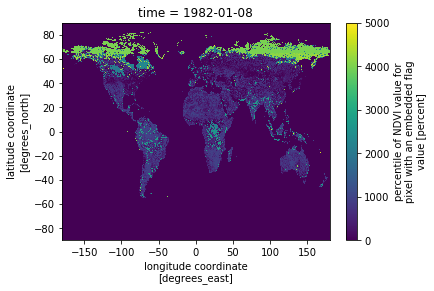

In [10]:
gimms_ndvi_percentile[0].plot()

In [11]:
gimms_ndvi_ndvi = gimms_ndvi['ndvi']

In [12]:
gimms_ndvi_ndvi

<xarray.DataArray 'ndvi' (time: 12, lat: 2160, lon: 4320)>
[111974400 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 1982-01-08 1982-01-24 ... 1982-06-23
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
Attributes:
    units:          1
    scale:          x 10000
    valid_range:    [-0.3  1. ]
    standard_name:  normalized_difference_vegetation_index
    long_name:      maximum normalized difference vegetation index (NDVI) ove...
    description:    pixels with ndvi = -5000 should be treated as missing data

In [19]:
modis_ld_gimms = []
for i in range(len(modis_ld_global)):
    modis_ld_gimms.append(modis_ld_global[i].interp_like(gimms_ndvi_ndvi[0], method='nearest'))
modis_ld_gimms = xr.concat(modis_ld_gimms, dim = 'year') 

In [20]:
modis_ld_gimms

<xarray.DataArray 'modis_landcover' (year: 22, lat: 2160, lon: 4320)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0

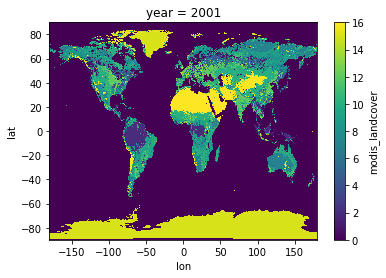

In [21]:
modis_ld_gimms[0].plot()

In [22]:
np.unique(modis_ld_gimms[0])

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

In [23]:
modis_ld_gimms = modis_ld_gimms.where(modis_ld_gimms>0)
modis_ld_gimms = modis_ld_gimms.where(modis_ld_gimms<12)

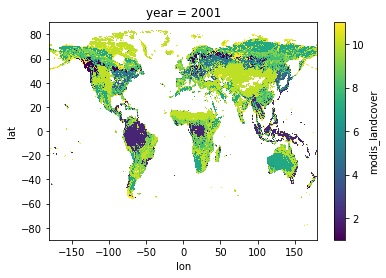

In [24]:
modis_ld_gimms[0].plot()

In [25]:
ld_change_gimms =  xr.apply_ufunc(
    ld_unchanged,
    modis_ld_gimms,
    input_core_dims=[['year']],
    output_core_dims=[[]],
    vectorize= True
)

In [26]:
modis_ld_gimms_filtered = modis_ld_gimms.where(ld_change_gimms == 0)

In [27]:
modis_ld_gimms_filtered

<xarray.DataArray 'modis_landcover' (year: 22, lat: 2160, lon: 4320)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * year     (year) int64 2001 2002 2003 2004 2005 ... 2018 2019 2020 2021 2022
  * lat      (lat) float64 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0

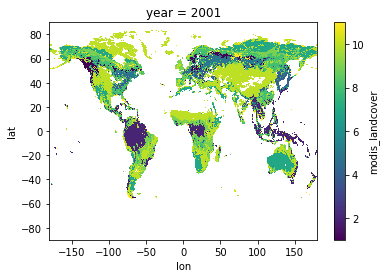

In [28]:
modis_ld_gimms_filtered[0].plot()

In [30]:
ld_change_gimms_check =  xr.apply_ufunc(
    ld_unchanged,
    modis_ld_gimms_filtered,
    input_core_dims=[['year']],
    output_core_dims=[[]],
    vectorize= True
)

In [31]:
np.unique(ld_change_gimms_check.values)

array([0, 2])

In [32]:
modis_ld_gimms_filtered[0].to_netcdf("G:/modis_landcover/landcover_gimms_mask.nc", 
                          encoding = {'modis_landcover':{"zlib": True, "complevel": 9}})